<a href="https://colab.research.google.com/github/YakoYakoko/Estudios/blob/main/Copia_de_Regresion_polonomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/andonians/random-linear-regression

In [32]:
train <- read.csv("train.csv")
test <- read.csv("test.csv")

explorar la estructura del dataframe que contiene ambos conjuntos:

In [33]:
str(train)
str(test)

'data.frame':	700 obs. of  2 variables:
 $ x: num  24 50 15 38 87 36 12 81 25 5 ...
 $ y: num  21.5 47.5 17.2 36.6 87.3 ...
'data.frame':	300 obs. of  2 variables:
 $ x: int  77 21 22 20 36 15 62 95 20 5 ...
 $ y: num  79.8 23.2 25.6 17.9 41.8 ...


graficar el conjunto de entrenamiento.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


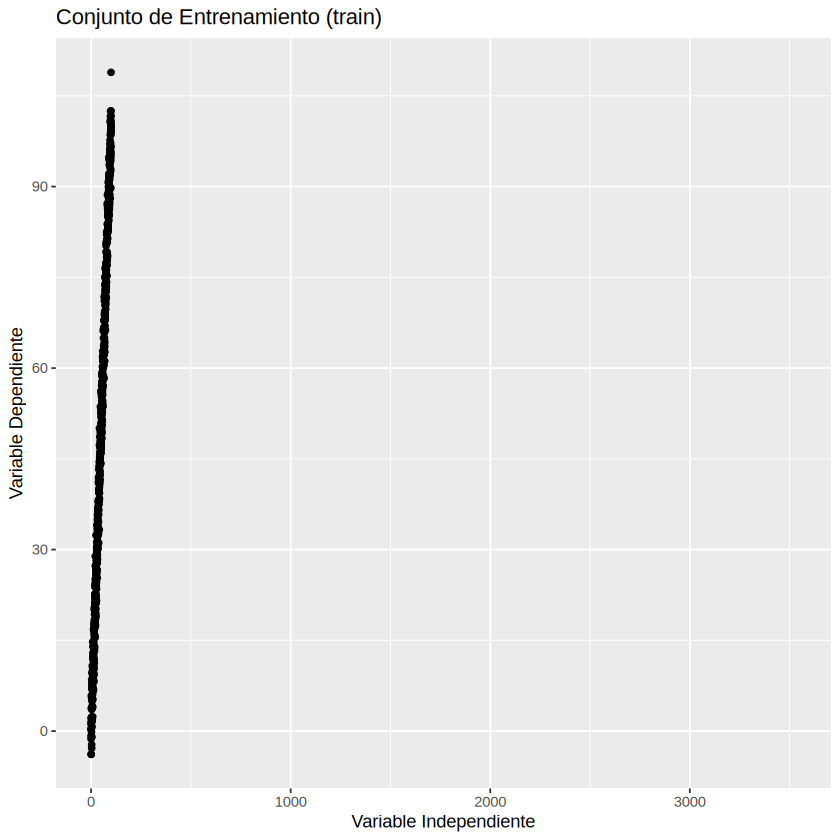

In [34]:
library(ggplot2)
ggplot() + geom_point(data = train, aes(x = x, y = y)) +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Conjunto de Entrenamiento (train)")

Aplicar una regresión sobre estos datos implica obtener la línea recta que mejor ajuste la relación existente entre la variable independiente y la variable dependiente. Para ello, vamos a crear un regresor haciendo uso de la función lm del paquete stats:

In [35]:
set.seed(1234)
regresor <- lm(y ~ x, data = train)

Una vez creado el regresor, podemos explorar los resultados y calidad del ajuste haciendo uso de la función summary:

In [36]:
summary(regresor)


Call:
lm(formula = y ~ x, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.1523 -2.0179  0.0325  1.8573  8.9132 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.107265   0.212170  -0.506    0.613    
x            1.000656   0.003672 272.510   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.809 on 697 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.9907,	Adjusted R-squared:  0.9907 
F-statistic: 7.426e+04 on 1 and 697 DF,  p-value: < 2.2e-16


vamos a crear un vector de predicciones basado en el propio conjunto de entrenamiento, y con este vector podremos visualizar la curva de ajuste de los datos. Para obtener las predicciones, hacemos uso de la función predict:

In [37]:
y_predict <- predict(regresor, train)

Luego, construimos la gráfica adecuada:

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


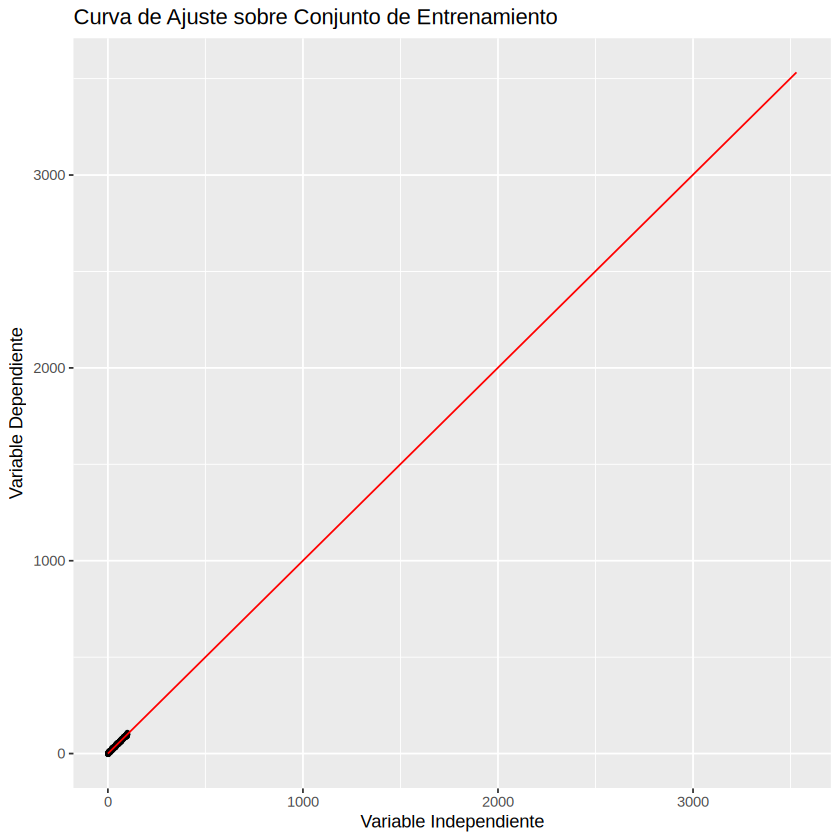

In [38]:
ggplot() + geom_point(data = train, aes(x = x, y = y), size = 0.9) +
  geom_line(aes( x = train$x, y = y_predict), color = "red") +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Curva de Ajuste sobre Conjunto de Entrenamiento")

Ahora, ya que contamos con nuestro regresor, vamos a realizar predicciones sobre el conjunto de validación, el cual contiene puntos que no fueron usados durante el entrenamiento:

In [39]:
y_test_predict <- predict(regresor, test)

Grafiquemos entonces tanto el conjunto de validación como la curva de ajuste:

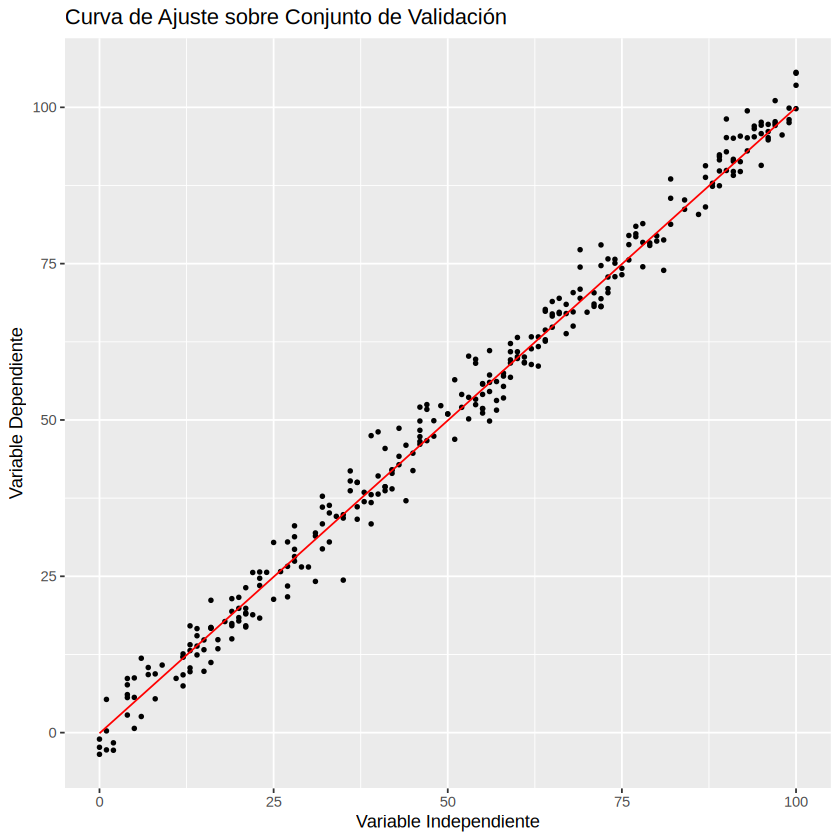

In [40]:
ggplot() + geom_point(data = test, aes(x = x, y = y), size = 0.9) +
  geom_line(aes( x = test$x, y = y_test_predict), color = "red") +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Curva de Ajuste sobre Conjunto de Validación")

veamos la correlación existente entre los valores y del conjunto de entrenamiento, y los valores predichos para dicho conjunto. Para ello, usamos la función cor:

In [41]:
cor(test$y, y_test_predict)

[1] 0.9945453

Por último, ya que tenemos nuestro modelo regresor listo, si deseáramos tener una predicción predicción particular para un valor cualquiera de x, podemos hacerlo de la siguiente manera:

In [42]:
predict_value <- predict(regresor, data.frame(x = c(58.7)))
predict_value

1 
58.63126

En este punto es importante mencionar que la función predict espera como argumento de la variable independiente un dataframe, por lo que es necesario convertir el valor 58.7 seleccionado a tal tipo de dato como se observa en el código anterior.

**Regresión Polinomial (Polynomial Regression)**


A efectos de la implementación de la regresión polinomial, vamos a utilizar un nuevo conjunto de datos que no tiene características lineales como el anterior
Generar de manera artificial a partir de ecuaciones matemáticas específicas 100 puntos que tengan un comportamiento no lineal. como el que se muestra en la figura.
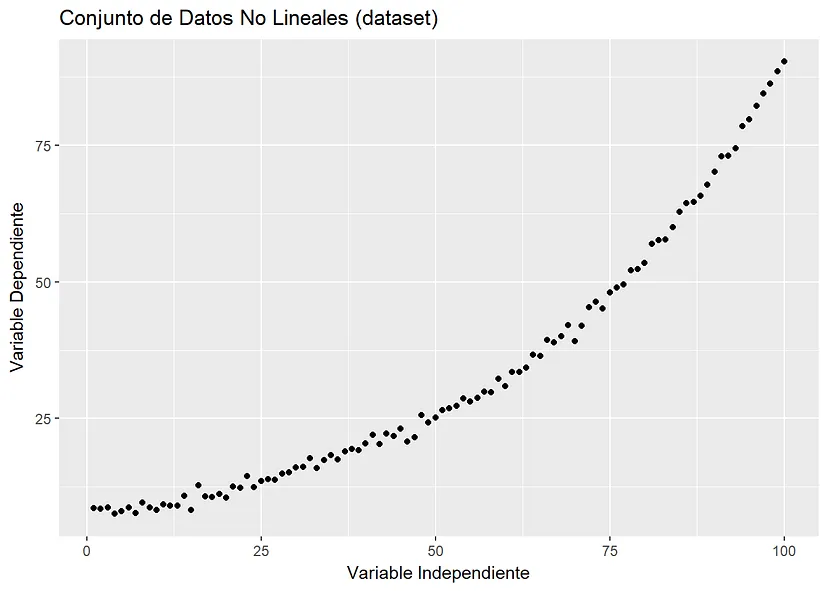
A partir de estos datos, crearemos los conjuntos de entrenamiento y validación a ser aplicados al modelo. En primer lugar, carguemos el nuevo conjunto y observemos su estructura:

In [43]:
#  Generar 100 puntos para la variable independiente (x) del 1 al 100
x <- 1:100

#  Generar ruido aleatorio para simular la dispersión natural de los datos
set.seed(123)
ruido <- rnorm(100, mean = 0, sd = 1.5)

y <- 0.011 * (x^2) - 0.25 * x + 10 + ruido


dataset <- data.frame(x = x, y = y)


str(dataset)

'data.frame':	100 obs. of  2 variables:
 $ x: int  1 2 3 4 5 6 7 8 9 10 ...
 $ y: num  8.92 9.2 11.69 9.28 9.22 ...


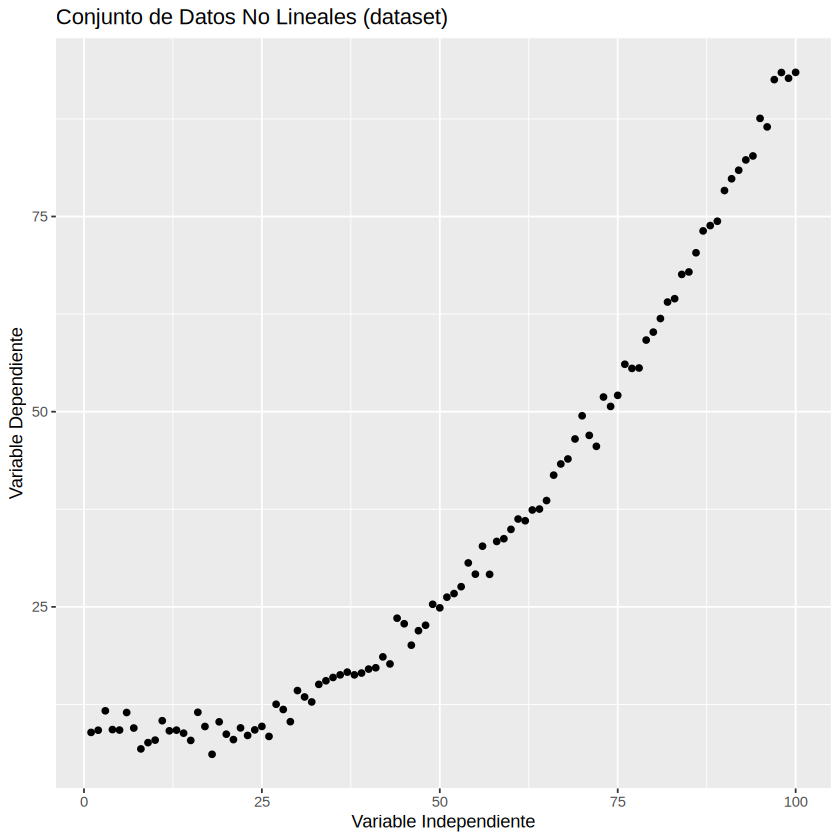

In [44]:
ggplot() + geom_point(data = dataset, aes(x = x, y = y)) +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Conjunto de Datos No Lineales (dataset)")

 Cuando se habla de **Regresión Polinomial**, se busca el producir entonces una ecuación de ajuste de las variables dependiente — independiente que tenga la forma
 $$y=a+bx+cx^2+…+Nx^n,$$
 en donde n es el grado del polinomio. Es decir, se introducen al modelo términos polinomiales de la variable independiente hasta lograr el mejor ajuste a los datos.

Ahora bien, antes de crear el modelo de regresión, vamos a generar, a partir del dataset, los conjuntos de entrenamiento y validación. Para ello vamos a seleccionar observaciones al azar dentro del dataset y asignaremos una porción como nltrain y el resto como nltest.

Para ello, utilizaremos la función sample.split del paquete caTools:

In [45]:
install.packages("caTools")
library(caTools)
split = sample.split(dataset$y, SplitRatio = 0.7)
nltrain = subset(dataset, split == TRUE)
nltest = subset(dataset, split == FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



El argumento SplitRatio refleja la proporción entre de elementos a seleccionar entre entrenamiento / validación, que en este caso colocamos en 0.7 de modo que 70 observaciones correspondan a entrenamiento y las 30 restantes a validación.

Ahora bien, ya que los conjuntos de datos están creados, para realizar la regresión polinomial, vamos a introducir, en primer lugar, un término de segundo grado a nuestros datos de entrenamiento a fin de que el regresor pueda ser polinomial:

In [46]:
nltrain$x2 <- nltrain$x^2

Al inspeccionar de nuevo el conjunto de entrenamiento:

In [47]:
str(nltrain)

'data.frame':	70 obs. of  3 variables:
 $ x : int  1 3 4 5 7 8 9 10 11 12 ...
 $ y : num  8.92 11.69 9.28 9.22 9.48 ...
 $ x2: num  1 9 16 25 49 64 81 100 121 144 ...


Vemos que al dataframe se le incorporó una columna que representa el cuadrado de la variable independiente x.

Ahora, podemos construir nuestro modelo de regresión polinomial:

In [48]:
set.seed(1234)
regresor_poly <- lm(y ~ x + x2, data = nltrain)

Al aplicar la función summary a nuestro nuevo regresor tenemos:

In [49]:
summary(regresor_poly)


Call:
lm(formula = y ~ x + x2, data = nltrain)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7149 -0.8392  0.0938  0.8491  3.2581 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 10.0219876  0.4783924   20.95   <2e-16 ***
x           -0.2565590  0.0227966  -11.25   <2e-16 ***
x2           0.0111353  0.0002241   49.70   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.347 on 67 degrees of freedom
Multiple R-squared:  0.9974,	Adjusted R-squared:  0.9973 
F-statistic: 1.269e+04 on 2 and 67 DF,  p-value: < 2.2e-16


Como puede verse, tanto la variable x como la variable x2 son relevantes a efectos de la predicción (valores pequeños del p-value) y se obtiene un R^2 de (???).


Obtengamos las predicciones para el conjunto de entrenamiento y elaboremos la gráfica del modelo obtenido:

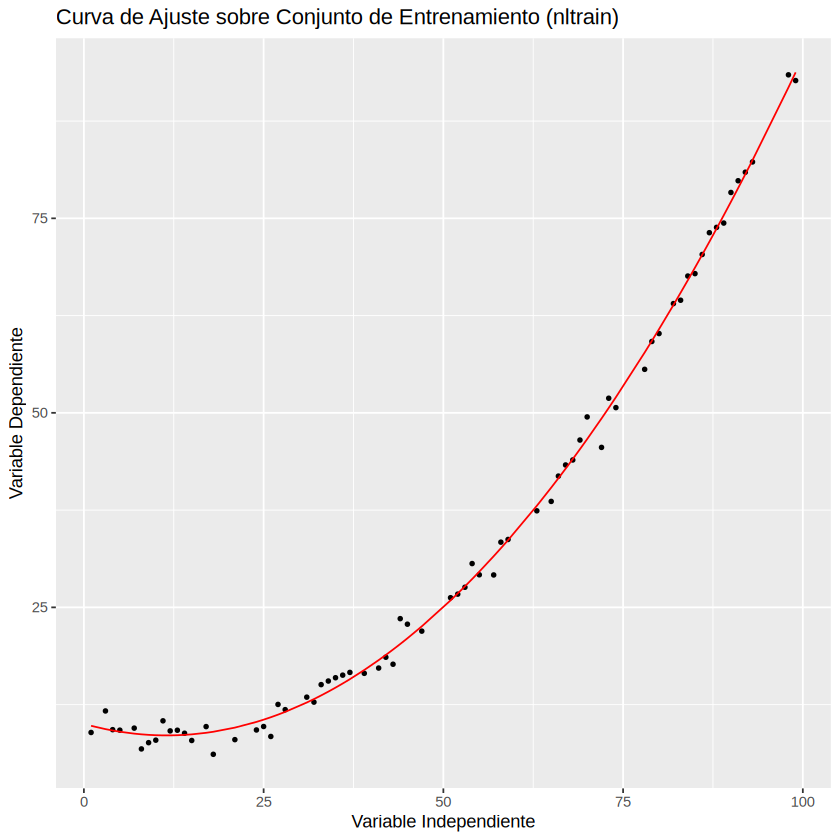

In [50]:
y_poly_predict <- predict(regresor_poly, nltrain)
ggplot() + geom_point(data = nltrain, aes(x = x, y = y), size = 0.9) +
  geom_line(aes( x = nltrain$x, y = y_poly_predict), color = "red") +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Curva de Ajuste sobre Conjunto de Entrenamiento (nltrain)")

Como puede verse, tanto la variable x como la variable x2 son relevantes a efectos de la predicción (valores pequeños del p-value) y se obtiene un R^2 de 0.9974.

Ahora, ¿qué ocurre si incorporamos más órdenes al polinomio? Hagamos la prueba:


Call:
lm(formula = y ~ x + x2 + x3, data = nltrain)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.6311 -0.8055  0.1428  0.8219  3.2292 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  9.834e+00  6.516e-01  15.093  < 2e-16 ***
x           -2.338e-01  5.797e-02  -4.032 0.000146 ***
x2           1.056e-02  1.369e-03   7.710 8.74e-11 ***
x3           3.913e-06  9.139e-06   0.428 0.669894    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.355 on 66 degrees of freedom
Multiple R-squared:  0.9974,	Adjusted R-squared:  0.9973 
F-statistic:  8358 on 3 and 66 DF,  p-value: < 2.2e-16


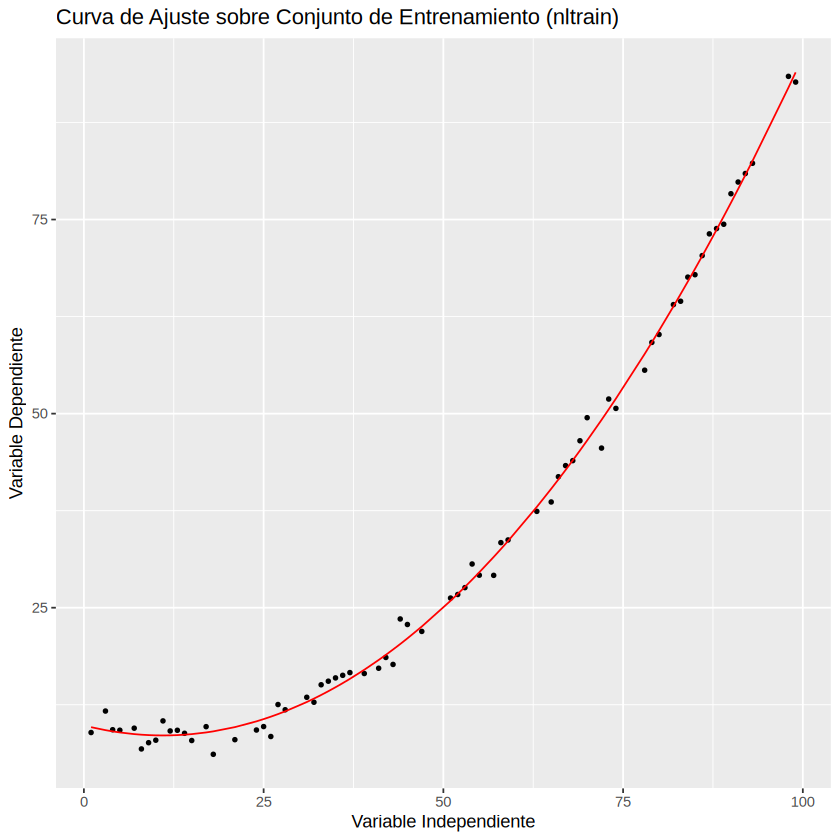

In [51]:
nltrain$x3 <- nltrain$x^3
regresor_poly <- lm(y ~ x + x2 + x3, data = nltrain)
summary(regresor_poly)
y_poly_predict <- predict(regresor_poly, nltrain)
ggplot() +
geom_point(data = nltrain, aes(x = x, y = y), size = 0.9) +
geom_line(aes( x = nltrain$x, y = y_poly_predict), color = "red") +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Curva de Ajuste sobre Conjunto de Entrenamiento (nltrain)")

Justificar los resultados obtenidos y generar conclusiones

En función de este resultado, podemos entonces incorporar los elementos polinomiales al conjunto de validación, y aplicar la regresión respectiva:

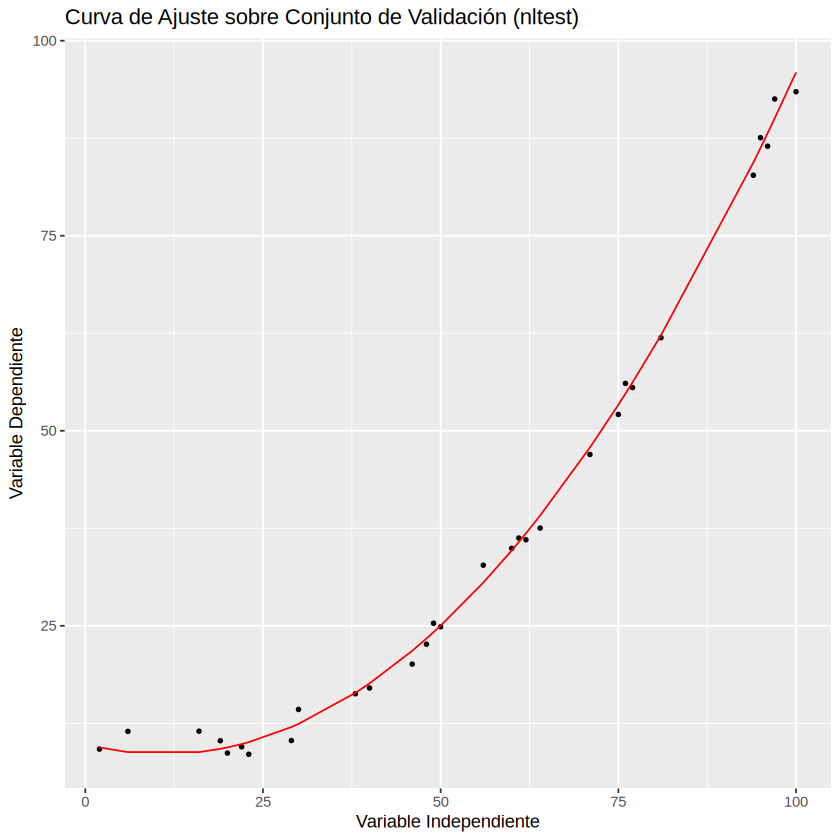

In [52]:
nltest$x2 <- nltest$x^2
nltest$x3 <- nltest$x^3
y_poly_test_predict <- predict(regresor_poly, nltest)
ggplot() + geom_point(data = nltest, aes(x = x, y = y), size = 0.9) +
  geom_line(aes( x = nltest$x, y = y_poly_test_predict), color = "red") +
  xlab("Variable Independiente") +
  ylab("Variable Dependiente") +
  ggtitle("Curva de Ajuste sobre Conjunto de Validación (nltest)")

Las curvas de ajuste producidas, tanto para los datos de entrenamiento como para validación, reproducen entonces el comportamiento no lineal de los datos, y sirven como modelos para predecir cualquier valor nuevo de la variable independiente que se tome, por ejemplo:

In [53]:
predict_value_poly <- predict(regresor_poly, data.frame(x = 71,
                                                        x2 = 71^2,
                                                        x3 = 71^3))
predict_value_poly

1 
47.85539

**Análisis de los Resultados:**

Al comparar el modelo polinomial de segundo grado ($y \sim x + x^2$) con el modelo de tercer grado ($y \sim x + x^2 + x^3$), podemos observar lo siguiente en las estadísticas:

1. **Significancia de las variables (P-value):** En el modelo de grado 2, tanto $x$ como $x^2$ tienen un *p-value* ínfimo (`< 2e-16`), lo que nos confirma que ambas son altamente significativas y necesarias para la predicción. Sin embargo, al probar el modelo de grado 3, vemos que la nueva variable $x^3$ arroja un *p-value* de **0.669894**. Al ser este valor mucho mayor al umbral típico de 0.05, estadísticamente hablando, el término al cubo no aporta información relevante al modelo.   

2. **Métrica de Ajuste ($R^2$):** El $R^2$ múltiple es prácticamente idéntico en ambos casos (**0.9974**), indicando un ajuste excelente. No obstante, si miramos el $R^2$ ajustado (*Adjusted R-squared*, que penaliza el agregar variables que no sirven), vemos que se mantiene igual o incluso podría disminuir ligeramente al meter $x^3$.   

**Conclusiones:**

* **El modelo óptimo es el de segundo grado.** La curva de nuestros datos artificiales sigue un comportamiento claramente cuadrático (parabólico).
* **Agregar más grados no siempre es mejor.** Incorporar el término de tercer grado ($x^3$) no mejoró la capacidad predictiva del modelo y solo añadió complejidad matemática innecesaria. En *machine learning*, siempre debemos buscar el modelo más simple que resuelva el problema para evitar el sobreajuste (*overfitting*).   
* **Validación exitosa.** Como se aprecia en las gráficas, la línea de ajuste (roja) modela perfectamente la tendencia no lineal de los datos de entrenamiento. Cuando pasamos este modelo al conjunto de validación (`nltest`), vemos que logra generalizar muy bien, permitiéndonos predecir con alta precisión el valor de $y$ para cualquier entrada de $x$ que le proporcionemos.